# MNIST with Data Augmentation

## 載入套件

In [ ]:
import os, sys
from pathlib import Path
from typing import Any, Callable, List, Optional, Sized, Tuple, cast

import matplotlib.pyplot as plt
import numpy as np
import PIL.Image as Image
from skimage import io
from skimage.transform import resize
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import MNIST

## 設定參數

In [ ]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑
BATCH_SIZE = 1000  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'cpu'

## 定義資料增補函數

In [3]:
image_width = 28
train_transforms = transforms.Compose(
    [
        # transforms.ColorJitter(), # 亮度、飽和度、對比資料增補
        # 裁切部分圖像，再調整圖像尺寸
        transforms.RandomResizedCrop(image_width, scale=(0.8, 1.0)),
        transforms.RandomRotation(degrees=(-10, 10)),  # 旋轉 10 度
        # transforms.RandomHorizontalFlip(), # 水平翻轉
        # transforms.RandomAffine(10), # 仿射
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.1307,), std=(0.3081,)),
    ]
)

test_transforms = transforms.Compose(
    [
        transforms.Resize((image_width, image_width)),  # 調整圖像尺寸
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.1307,), std=(0.3081,)),
    ]
)

## 步驟1：載入 MNIST 手寫阿拉伯數字資料

In [4]:
# 下載 MNIST 手寫阿拉伯數字 訓練資料
train_ds = MNIST(PATH_DATASETS, train=True, download=True, transform=train_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# 下載測試資料
test_ds = MNIST(PATH_DATASETS, train=False, download=True, transform=test_transforms)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# 訓練/測試資料的維度
print(train_ds.data.shape, test_ds.data.shape)

100%|██████████| 9.91M/9.91M [00:03<00:00, 3.18MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 167kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.19MB/s]


torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


## 步驟2：資料清理，此步驟無需進行

## 步驟3：特徵工程，此步驟無需進行

## 步驟4：資料分割，此步驟無需進行，載入MNIST資料時，已經切割好了

## 步驟5：建立模型結構

In [5]:
# Conv2d 參數： in-channel, out-channel, kernel size, Stride, Padding
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x: torch.Tensor):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

## 步驟6：結合訓練資料及模型，進行模型訓練

In [ ]:
def train(model: nn.Module, device: str, train_loader: DataLoader, criterion, optimizer: optim.Optimizer, epoch: int):
    model.train()
    loss_list: list[float] = []
    data: torch.Tensor
    target: torch.Tensor
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output: torch.Tensor = model(data)
        # loss = F.nll_loss(output, target)
        loss: torch.Tensor = criterion(output, target)
        loss.backward()
        optimizer.step()

        if (batch_idx + 1) % 10 == 0:
            loss_list.append(loss.item())
            batch = (batch_idx + 1) * len(data)
            data_count = len(cast(Sized, train_loader.dataset))
            percentage = 100.0 * (batch_idx + 1) / len(cast(Sized, train_loader.dataset))
            print(f'Epoch {epoch}: [{batch:5d} / {data_count}] ({percentage:.0f} %)' + f'  Loss: {loss.item():.6f}')
    return loss_list

In [ ]:
def test(model: nn.Module, device: str, test_loader: DataLoader):
    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        data: torch.Tensor
        target: torch.Tensor
        for data, target in test_loader:
            # print(data.shape)
            # print(target)
            if type(data) == tuple:
                data = torch.FloatTensor(data)
            if type(target) == tuple:
                target = torch.Tensor(target)
            data, target = data.to(device), target.to(device)
            output: torch.Tensor = model(data)
            # test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            _, predicted = torch.max(output.data, 1)
            # print(predicted)
            correct += (predicted == target).sum().item()

    # 平均損失
    data_count = len(cast(Sized, test_loader.dataset))
    test_loss /= data_count
    # 顯示測試結果
    percentage = 100.0 * correct / data_count
    print(f'準確率: {correct}/{data_count} ({percentage:.2f}%)')

In [8]:
epochs = 5
lr = 1

# 建立模型
model = Net().to(device)

# 損失
criterion = F.nll_loss  # nn.CrossEntropyLoss()

# 設定優化器(optimizer)
optimizer = optim.Adadelta(model.parameters(), lr=lr)

loss_list = []
for epoch in range(1, epochs + 1):
    loss_list += train(model, device, train_loader, criterion, optimizer, epoch)
    # test(model, device, test_loader)
    optimizer.step()

Epoch 1: [10000 / 60000] (17 %)  Loss: 1.555173
Epoch 1: [20000 / 60000] (33 %)  Loss: 1.105943
Epoch 1: [30000 / 60000] (50 %)  Loss: 0.738833
Epoch 1: [40000 / 60000] (67 %)  Loss: 0.468498
Epoch 1: [50000 / 60000] (83 %)  Loss: 0.481999
Epoch 1: [60000 / 60000] (100 %)  Loss: 0.355725
Epoch 2: [10000 / 60000] (17 %)  Loss: 0.437513
Epoch 2: [20000 / 60000] (33 %)  Loss: 0.336209
Epoch 2: [30000 / 60000] (50 %)  Loss: 0.255794
Epoch 2: [40000 / 60000] (67 %)  Loss: 0.276180
Epoch 2: [50000 / 60000] (83 %)  Loss: 0.232870
Epoch 2: [60000 / 60000] (100 %)  Loss: 0.241607
Epoch 3: [10000 / 60000] (17 %)  Loss: 0.177541
Epoch 3: [20000 / 60000] (33 %)  Loss: 0.162045
Epoch 3: [30000 / 60000] (50 %)  Loss: 0.183406
Epoch 3: [40000 / 60000] (67 %)  Loss: 0.181264
Epoch 3: [50000 / 60000] (83 %)  Loss: 0.188978
Epoch 3: [60000 / 60000] (100 %)  Loss: 0.203816
Epoch 4: [10000 / 60000] (17 %)  Loss: 0.191028
Epoch 4: [20000 / 60000] (33 %)  Loss: 0.134252
Epoch 4: [30000 / 60000] (50 %)  Loss

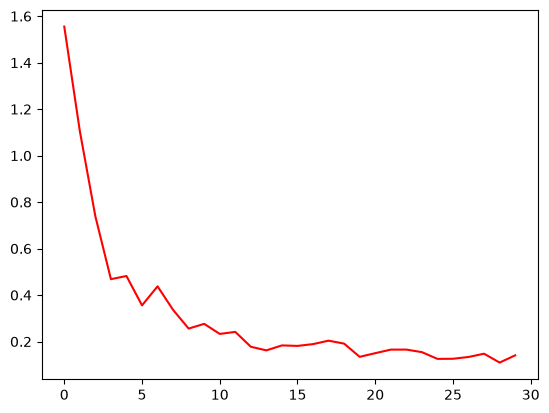

In [9]:
# 對訓練過程的損失繪圖
plt.plot(loss_list, 'r')

## 步驟7：評分(Score Model)

In [10]:
test(model, device, test_loader)

準確率: 9732/10000 (97.32%)


In [11]:
# 實際預測 20 筆資料
predictions: list[str] = []
with torch.no_grad():
    for i in range(20):
        data: torch.Tensor = test_ds[i][0]
        data = data.reshape(1, *data.shape).to(device)
        output = torch.argmax(model(data), dim=-1)
        predictions.append(str(output.item()))

# 比對
print('actual    :', test_ds.targets[0:20].numpy())
print('prediction: ', ' '.join(predictions[0:20]))

actual    : [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
prediction:  7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4


## 步驟8：評估，暫不進行

## 步驟9：模型佈署

## 步驟10：新資料預測

### 方法1：使用 Pillow 套件

In [12]:
# 顯示圖像
def imshow(X: np.ndarray) -> None:
    # 繪製點陣圖，cmap='gray':灰階
    plt.imshow(X.reshape(28, 28), cmap='gray')

    # 隱藏刻度
    plt.axis('off')

    # 顯示圖形
    plt.show()

In [ ]:
# 使用PIL讀取檔案，像素介於[0, 255]
data_shape = data.shape

for i in range(10):
    uploaded_file = base_path / f'myDigits/{i}.png'
    image1 = Image.open(uploaded_file).convert('L')

    # 縮為 (28, 28) 大小的影像
    image_resized = image1.resize((int(data_shape[2]), int(data_shape[3])))
    X1 = np.array(image_resized).reshape([1] + list(data_shape)[1:])
    # 反轉顏色，顏色0為白色，與 RGB 色碼不同，它的 0 為黑色
    X1 = 1.0 - (X1 / 255)

    # 圖像轉換
    X1 = (X1 - 0.1307) / 0.3081

    # 顯示轉換後的圖像
    # imshow(X1)

    X1 = torch.FloatTensor(X1).to(device)

    # 預測
    output: torch.Tensor = model(X1)
    # print(output, '\n')
    _, predicted = torch.max(output.data, 1)
    print(f'actual/prediction: {i} {predicted.item()}')

actual/prediction: 0 0
actual/prediction: 1 1
actual/prediction: 2 3
actual/prediction: 3 3
actual/prediction: 4 7
actual/prediction: 5 5
actual/prediction: 6 5
actual/prediction: 7 7
actual/prediction: 8 8
actual/prediction: 9 7


### 方法2：使用 skimage 套件

In [ ]:
# 使用 skimage 讀取檔案，像素介於[0, 1]
# 讀取影像並轉為單色
for i in range(10):
    uploaded_file = base_path / f'myDigits/{i}.png'
    image1 = io.imread(uploaded_file, as_gray=True)

    # 縮為 (28, 28) 大小的影像
    image_resized = np.asarray(resize(image1, tuple(data_shape)[2:], anti_aliasing=True))
    X1 = image_resized.reshape([1] + list(data_shape)[1:])
    # 反轉顏色，顏色0為白色，與 RGB 色碼不同，它的 0 為黑色
    X1 = 1.0 - X1

    # 圖像轉換
    X1 = (X1 - 0.1307) / 0.3081

    # 顯示轉換後的圖像
    # imshow(X1)

    X1 = torch.FloatTensor(X1).to(device)

    # 預測
    output = model(X1)
    _, predicted = torch.max(output.data, 1)
    print(f'actual/prediction: {i} {predicted.item()}')

actual/prediction: 0 0
actual/prediction: 1 1
actual/prediction: 2 3
actual/prediction: 3 3
actual/prediction: 4 7
actual/prediction: 5 5
actual/prediction: 6 5
actual/prediction: 7 7
actual/prediction: 8 8
actual/prediction: 9 7


### 方法3：使用自訂資料集

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(
        self,
        img_dir: str | Path,
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
        to_gray: bool = False,
        size: int = 28,
    ) -> None:
        self.img_labels = [file_name for file_name in os.listdir(img_dir)]
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform
        self.to_gray = to_gray
        self.size = size

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx: int) -> Tuple[Any, int]:
        # 組合檔案完整路徑
        img_path = os.path.join(self.img_dir, self.img_labels[idx])
        # 讀取圖檔
        mode = 'L' if self.to_gray else 'RGB'
        image = Image.open(img_path, mode='r').convert(mode)
        image = Image.fromarray(1.0 - (np.array(image) / 255))

        # print(image.shape)
        # 去除副檔名
        label = int(self.img_labels[idx].split('.')[0])

        # 轉換
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)

        return image, label

### 預測

In [ ]:
ds = CustomImageDataset(base_path / 'myDigits', to_gray=True, transform=test_transforms)
data_loader = DataLoader(ds, batch_size=10, shuffle=False)

test(model, device, data_loader)

準確率: 6/10000 (0.06%)


### 驗證

In [17]:
model.eval()
test_loss = 0.0
correct = 0
with torch.no_grad():
    data: torch.Tensor
    target: torch.Tensor
    for data, target in data_loader:
        print(target)
        data, target = data.to(device), target.to(device)

        # 預測
        output: torch.Tensor = model(data)
        _, predicted = torch.max(output.data, 1)
        correct += (predicted == target).sum().item()
        print(predicted)

tensor([9, 5, 4, 1, 3, 8, 2, 6, 7, 0])
tensor([7, 5, 7, 1, 3, 8, 3, 5, 7, 0])


In [ ]:
# 模型存檔
torch.save(model, base_path / 'cnn_augmentation_model.pt')